In [9]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# In round 1 of hyperparameter tuning we considered batch_size, learning rate, optimizer, and width. In round 2 
# we considered depth, dropout and threshold. 

with open('../data/hyperparameters/best_hyperparameters_round_3_1.txt', 'r') as file:
    lines = file.readlines()

data = []
lines

['Run ID\tauROC\tHyperparameters\tWidth/Depth\t#Params\n',
 "0\t0.8248479962348938\t{'depth': 54, 'width': 244, 'dropout': 0.0, 'threshold': 0.4, 'weight_decay': 0.001}\t{'depth': 54, 'width': 244, 'dropout': 0.0, 'threshold': 0.4, 'weight_decay': 0.001}\t4.518518518518518\t303105\n",
 "1\t0.8225057125091553\t{'depth': 30, 'width': 68, 'dropout': 0.4, 'threshold': 0.25, 'weight_decay': 0.0}\t{'depth': 30, 'width': 68, 'dropout': 0.4, 'threshold': 0.25, 'weight_decay': 0.0}\t2.2666666666666666\t303105\n",
 "2\t0.8235106468200684\t{'depth': 14, 'width': 4, 'dropout': 0.5, 'threshold': 0.2, 'weight_decay': 0.1}\t{'depth': 14, 'width': 4, 'dropout': 0.5, 'threshold': 0.2, 'weight_decay': 0.1}\t0.2857142857142857\t303105\n",
 "3\t0.8298574090003967\t{'depth': 14, 'width': 180, 'dropout': 0.2, 'threshold': 0.55, 'weight_decay': 0.01}\t{'depth': 14, 'width': 180, 'dropout': 0.2, 'threshold': 0.55, 'weight_decay': 0.01}\t12.857142857142858\t303105\n",
 "4\t0.825566291809082\t{'depth': 18, 'wid

In [15]:
for line in lines[1:]:
    line = line.strip().split('\t')
    try:
        hyperparams = ast.literal_eval(line[2])  # Use ast.literal_eval
    except (SyntaxError, ValueError):
        print(f"Error evaluating literal on line: {line}")
        continue
        
    data.append([float(line[1])] + list(hyperparams.values()) + [float(line[4])] + [float(line[5])])

columns = ['Metric Value'] + list(hyperparams.keys()) + ['Width/Depth'] + ['#Params']
df = pd.DataFrame(data, columns=columns)
df = df.rename_axis('ID').reset_index()

df_sorted = df.sort_values(by='Metric Value', ascending=False)
df_sorted

,ID,Metric Value,depth,width,dropout,threshold,weight_decay,Width/Depth,#Params
3,3,0.829857,14,180,0.2,0.55,0.010,12.857143,303105.0
18,18,0.829857,14,180,0.2,0.55,0.010,12.857143,303105.0
5,5,0.826190,6,68,0.4,0.60,0.000,11.333333,303105.0
20,20,0.826190,6,68,0.4,0.60,0.000,11.333333,303105.0
4,4,0.825566,18,228,0.0,0.25,0.001,12.666667,303105.0
19,19,0.825566,18,228,0.0,0.25,0.001,12.666667,303105.0
13,13,0.825477,18,4,0.2,0.75,0.001,0.222222,303105.0
28,28,0.825477,18,4,0.2,0.75,0.001,0.222222,303105.0
0,0,0.824848,54,244,0.0,0.40,0.001,4.518519,303105.0
15,15,0.824848,54,244,0.0,0.40,0.001,4.518519,303105.0


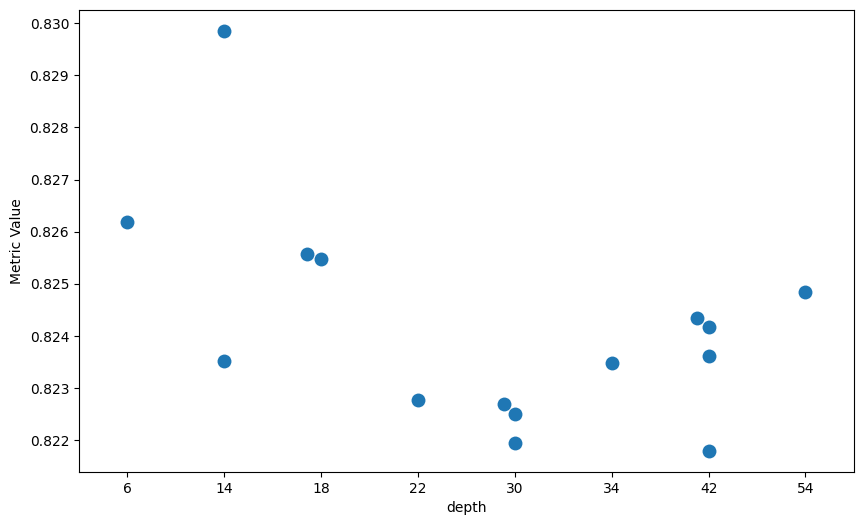

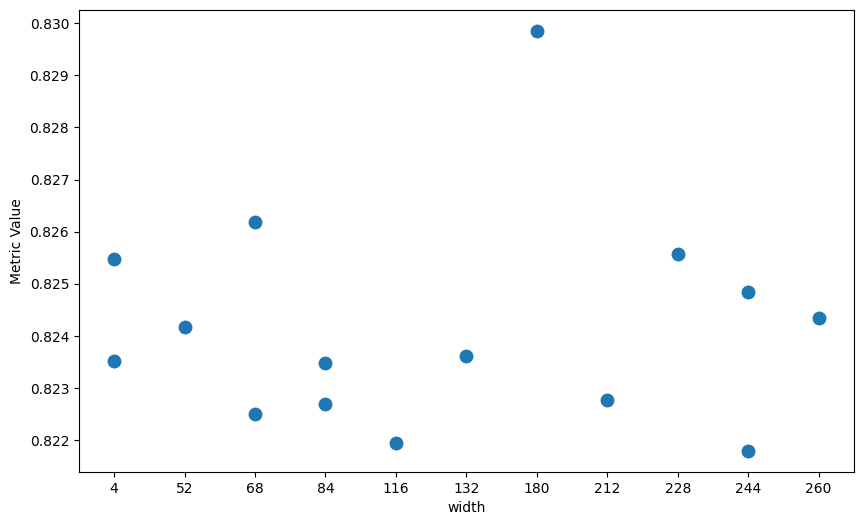

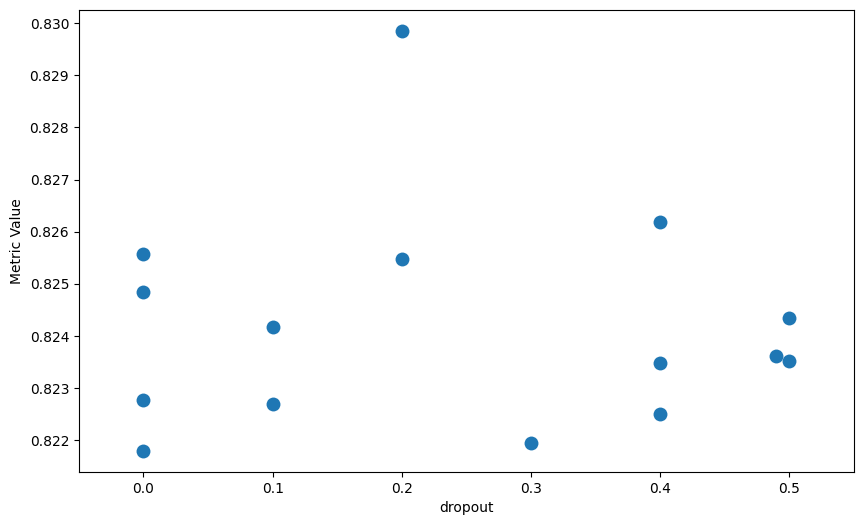

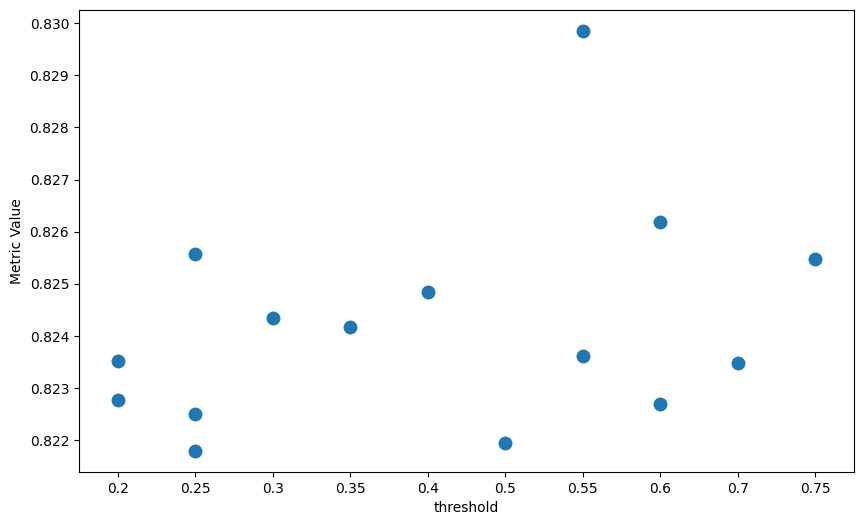

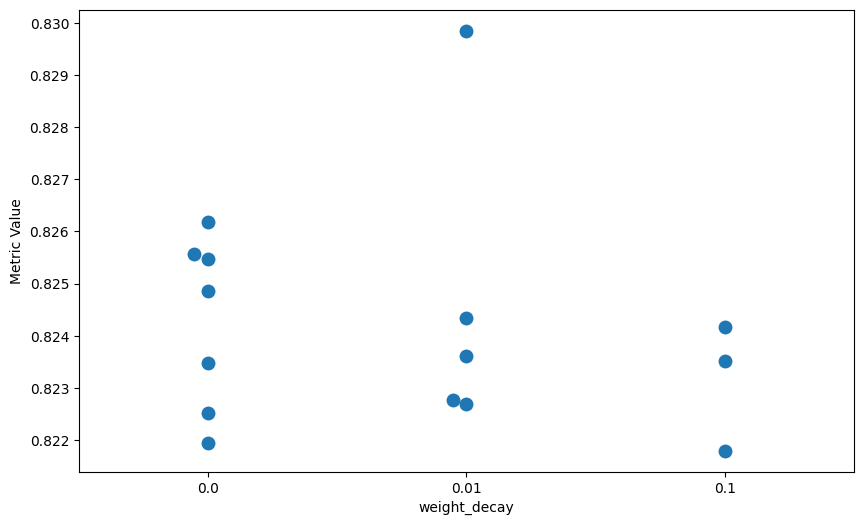

In [6]:
for hyperparam in list(hyperparams.keys()):
    rounded_values = df_sorted[hyperparam].round(2)  # Round to 2 decimal places
    df_rounded = pd.DataFrame({hyperparam: rounded_values, 'Metric Value': df_sorted['Metric Value']})
    plt.figure(figsize=(10, 6))
    sns.swarmplot(data=df_rounded, x=hyperparam, y='Metric Value', s=10)
    #plt.title(f'Swarm Plot of Metric Value vs {hyperparam}')
    plt.xlabel(hyperparam)
    plt.ylabel('Metric Value')
    plt.savefig(f"../plots/hyperparam_optimization/{hyperparam}_swarm_2.pdf", dpi=600) 
    plt.show()